## Transcriptomics Quality Check



In [2]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from corneto.io import import_cobra_model
from cobra.io import read_sbml_model

 Loading the Data

In [23]:
# Load your data (genes as rows, samples as columns)
df = pd.read_csv('/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Pvulgatus/Pvulgatus_All.csv', index_col=0)  
model = read_sbml_model("/scratch/rebernig/VR002_Model_Analysis/Output/Curated_Models_Elena/P.Vulgatus/Confidence_Levels_Biomass/curated.xml")
df = np.log2(df + 1)
df

,sample11,sample3,sample7,sample14,sample17,sample20,sample45,sample46,sample85,sample15,sample18,sample21
Name,,,,,,,,,,,,
PV_ATCC8482_00001,6.405821,5.785532,5.383094,6.994358,6.832105,4.934425,7.763770,8.125020,8.120355,6.964667,6.733667,5.617426
PV_ATCC8482_00002,7.920623,7.946415,6.528029,7.425771,7.817885,7.211420,5.330764,6.736585,7.315306,8.194559,7.629252,6.749606
PV_ATCC8482_00003,7.390187,7.495938,7.867613,7.888909,8.384506,6.109430,7.684811,8.030682,7.976691,7.525810,8.229178,5.872377
PV_ATCC8482_00004,5.190688,5.337474,4.494145,5.885729,5.654661,5.180897,6.362198,6.619741,6.229722,5.655354,5.185337,4.616407
PV_ATCC8482_00005,3.679328,0.000000,3.348730,4.133936,4.705882,3.286100,0.000000,0.000000,0.000000,3.425072,2.537179,1.802926
...,...,...,...,...,...,...,...,...,...,...,...,...
PV_ATCC8482_04292,1.585473,4.914373,4.423422,4.110129,3.424286,3.605009,0.000000,2.971918,5.490433,5.193210,3.583624,2.218796
PV_ATCC8482_04293,5.379214,0.000000,5.006956,5.051134,3.408769,3.222588,0.000000,0.000000,0.000000,4.786796,3.803184,3.553751
PV_ATCC8482_04294,4.456087,4.783562,3.539477,2.798730,3.806125,3.501503,7.095207,5.690283,5.524086,4.934438,4.683719,3.851738


### Spearman correlation (better for non-linear)

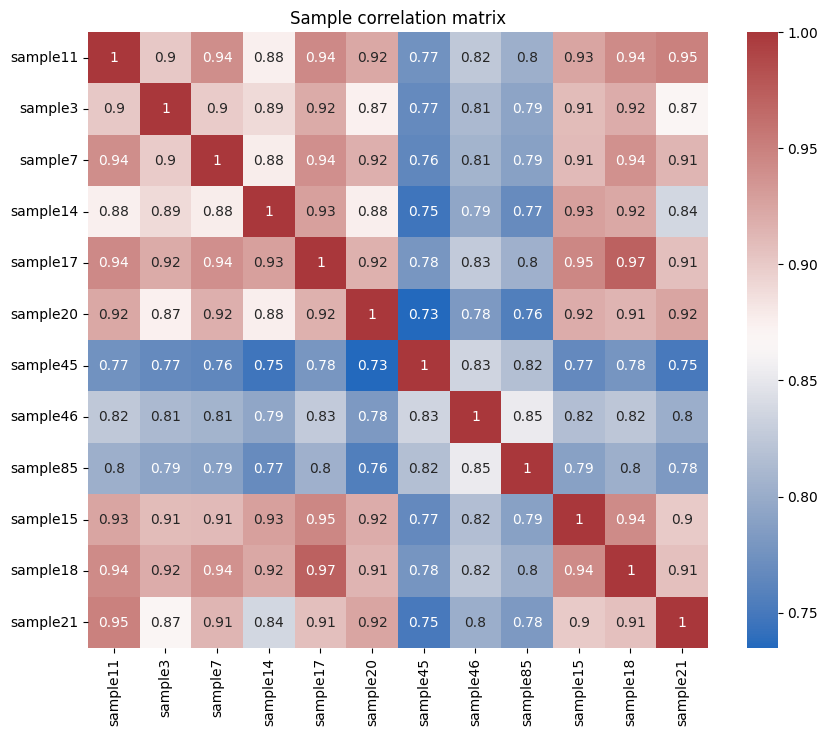

In [4]:
df.corr()
corr = df.corr(method='spearman')


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='vlag')
plt.title('Sample correlation matrix')
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Correlation_Test/Pvulgatus_Correlation")
plt.show()

Now a re clearer matrix, with blue < 0.80 < red

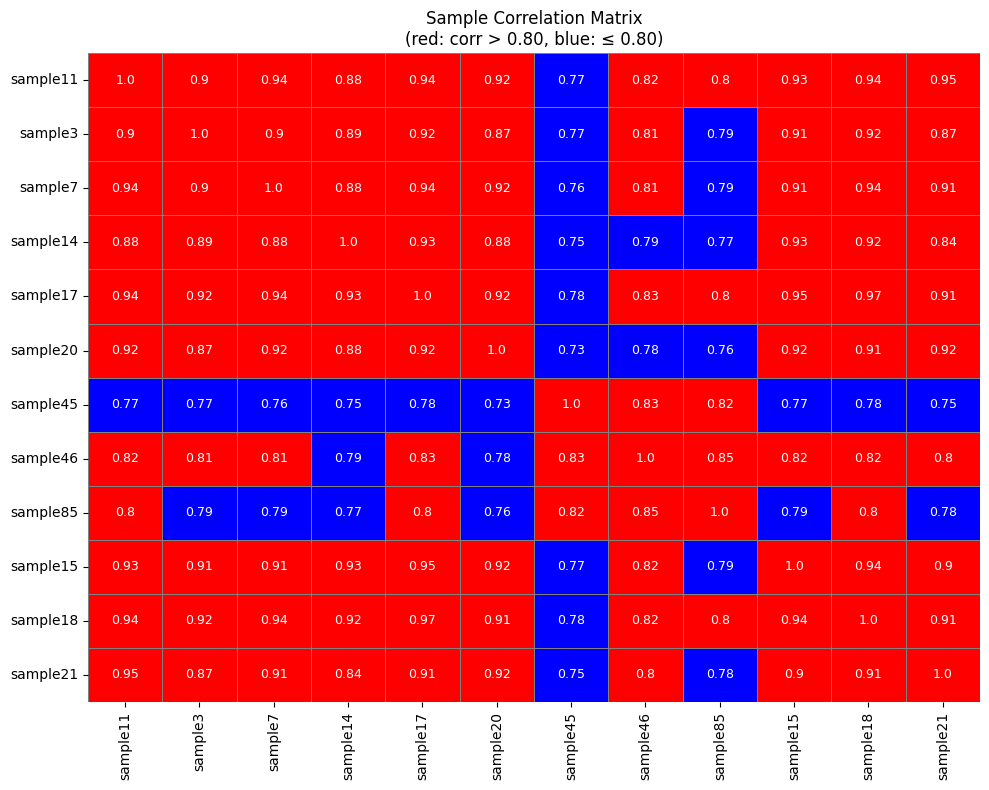

In [5]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# Make a copy of the correlation matrix for coloring
# Make a new matrix with values: 0 for ≤0.8, 1 for >0.8
mask_matrix = (corr.values > 0.80).astype(int)

cmap = ListedColormap(['blue', 'red'])
bounds = [-0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10,8))
sns.heatmap(
    mask_matrix, annot=corr.round(2), fmt='', 
    cmap=cmap, norm=norm, cbar=False, linewidths=0.5, linecolor='gray',
    xticklabels=corr.columns, yticklabels=corr.index, annot_kws={'fontsize':9}
)
plt.title('Sample Correlation Matrix\n(red: corr > 0.80, blue: ≤ 0.80)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

1) We can see weak correlation between sample14 and sample20 even they are both a biological replicates from Pvulgatus&Btheta
2) Weak correlation also between sample 15 and 21 both from B.Uniformis&Pvulgatus
3) Strong correlation between nearly all samples of P.vulgatus&B.theta and P.vulgatus&B.uniformis - seems already not to change much in the expression of P-vulgatus

### PCA Test

In [6]:
# Transpose: samples as rows, genes as columns (this is what PCA expects)
df_T = df.T



In [7]:
pca = PCA(n_components=2)
pc = pca.fit_transform(df_T)
pca_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_T.index)

# Map sample to condition
sample_to_condition = {
    'sample11': 'P.vulgatus',
    'sample3': 'P.vulgatus',
    'sample7': 'P.vulgatus',
    'sample14': 'P.vulgatus + BTheta',
    'sample17': 'P.vulgatus + BTheta',
    'sample20': 'P.vulgatus + BTheta',
    'sample45': 'Com21',
    'sample46': 'Com21',
    'sample85': 'Com21',
    'sample15': 'P.vulgatus + Buniformis',
    'sample18': 'P.vulgatus + Buniformis',
    'sample21': 'P.vulgatus + Buniformis'
}

pca_df['Condition'] = pca_df.index.map(sample_to_condition)

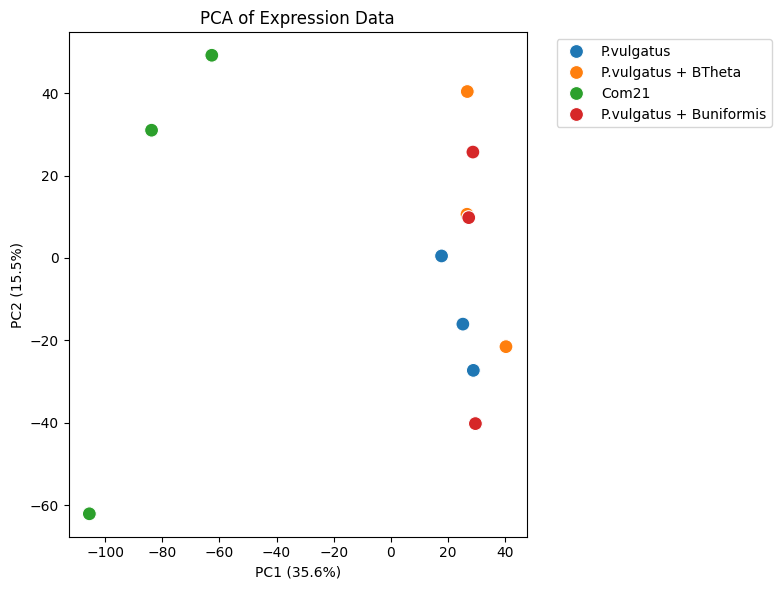

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/PCA/before_Gene_removal/Pvulgatus")
plt.show()

Data seems to be separated, especially between Com21 and the rest for PC1. But also bigger gaps between Replicates PC2. 

Next, we check for strong Outliers

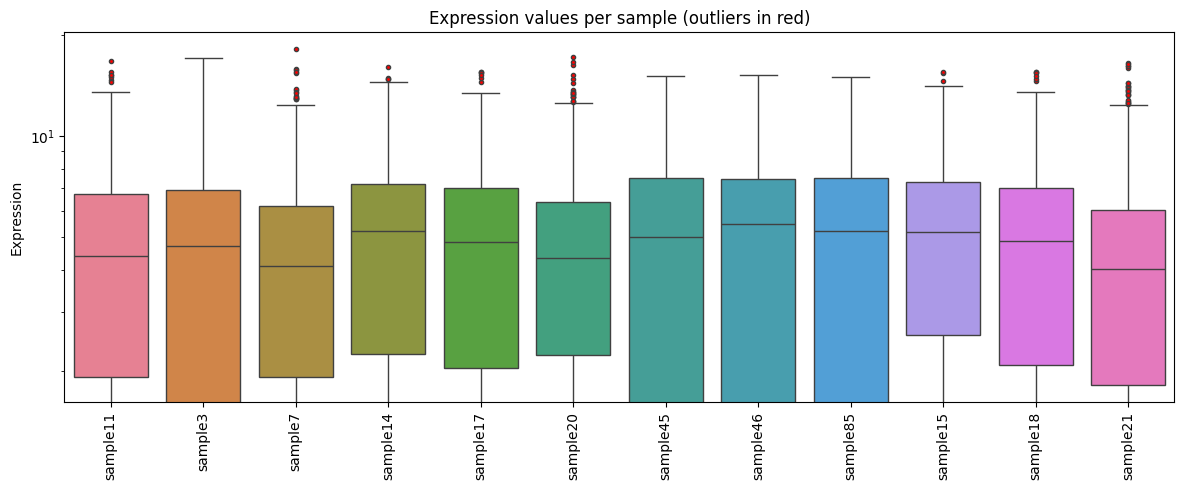

In [9]:
# Blotting Boxplots, to see outliers

plt.figure(figsize=(12,5))
sns.boxplot(data=df, orient='v', showfliers=True, fliersize=3, flierprops=dict(markerfacecolor='r', marker='o'))
plt.ylabel('Expression')
plt.title('Expression values per sample (outliers in red)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log",base=10)
plt.show()

In [10]:
max_per_gene=df.max()
max_per_gene

sample11    16.716691
sample3     17.098208
sample7     18.131600
sample14    16.010148
sample17    15.508262
sample20    17.149174
sample45    15.113018
sample46    15.204298
sample85    15.014916
sample15    15.472130
sample18    15.482521
sample21    16.513752
dtype: float64

### PCA Analyis without Outliers

Removing Outliers

In [11]:
# Create a mask for non-outlier values (True = not outlier)
mask = pd.DataFrame(True, index=df.index, columns=df.columns)
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask[col] = (df[col] >= lower) & (df[col] <= upper)

# Replace outliers with NaN
df_no_outliers = df.where(mask)

df_filled = df_no_outliers.fillna(df_no_outliers.median())

Showing the Data without Outliers

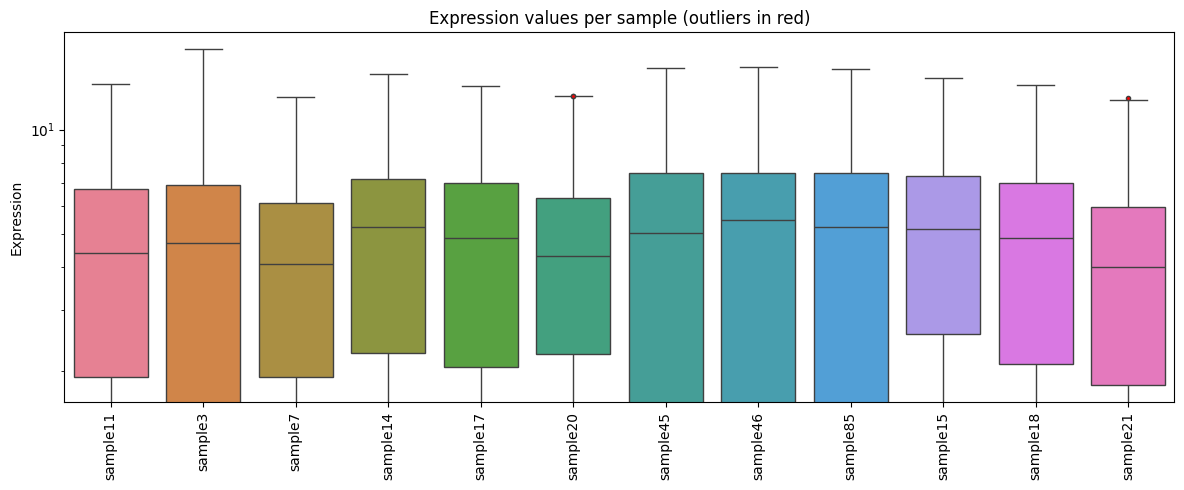

In [12]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df_filled, orient='v', showfliers=True, fliersize=3, flierprops=dict(markerfacecolor='r', marker='o'))
plt.ylabel('Expression')
plt.title('Expression values per sample (outliers in red)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log",base=10)
plt.show()

Now showing it in the PCA analysis

In [13]:
# Transpose: samples as rows, genes as columns (this is what PCA expects)
df_filled_T = df_filled.T



In [14]:
pca = PCA(n_components=2)
pc = pca.fit_transform(df_filled_T)
pca_df_filled = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_filled_T.index)

In [15]:
pca_df_filled['Condition'] = pca_df_filled.index.map(sample_to_condition)

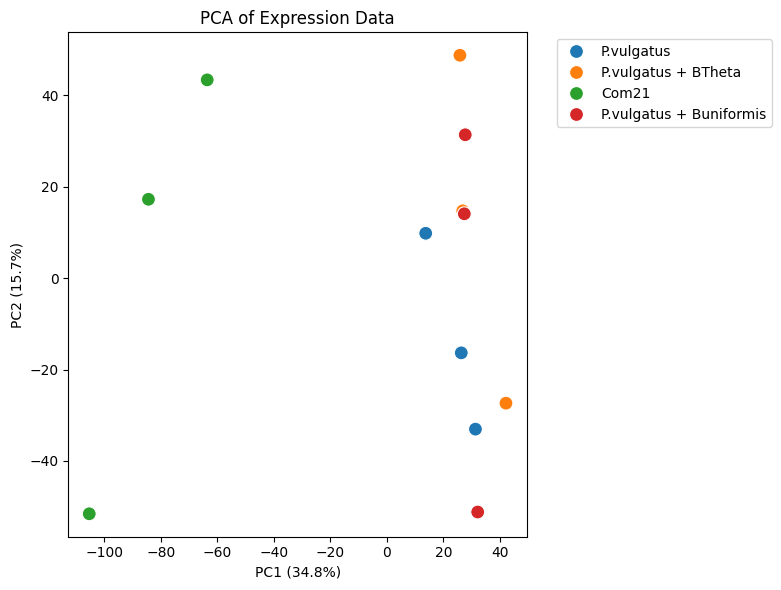

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df_filled, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Differences are minimal compared to the dataset with outliers

## Which Genes have high weight on PC2

Analysing min and max weights for PC2

In [17]:
a = pca.components_[1:].flatten()

In [18]:
max = pca.feature_names_in_[a.argmax()]
min = pca.feature_names_in_[a.argmin()]
max , min


('PV_ATCC8482_03920', 'PV_ATCC8482_03781')

In [19]:
com21_samples = ['sample45', 'sample46', 'sample85']
df_T[df_T.index.isin(com21_samples)].PV_ATCC8482_03920


sample45    10.540794
sample46    10.898902
sample85    10.552957
Name: PV_ATCC8482_03920, dtype: float64

In [20]:
com21_samples = ['sample45', 'sample46', 'sample85']
df_T[df_T.index.isin(com21_samples)].PV_ATCC8482_03781

sample45    7.472298
sample46    0.000000
sample85    0.000000
Name: PV_ATCC8482_03781, dtype: float64

We can see that weigths are coming from genes, in which at least on of the sample has no expression at all. 

## Data Cleaning - Removing of additional genes

Therefore, I further remove each Gene for a sample, if not all replicates have expression levels. Additonaly, I will remove all genes, which are not used in my model

1) First, look at the genes in our model 

In [29]:
# Get all gene objects
genes = model.genes

# Get gene IDs as a list
gene_ids = [gene.id for gene in genes]

# Print or save
print("Total genes:", len(gene_ids))
print(gene_ids[:10])  # print first 10 for a check

model_gene_set = set(gene_ids)

Total genes: 651
['PV_ATCC8482_01859', 'PV_ATCC8482_04213', 'PV_ATCC8482_03434', 'PV_ATCC8482_02027', 'PV_ATCC8482_02391', 'PV_ATCC8482_02394', 'PV_ATCC8482_02877', 'PV_ATCC8482_03140', 'PV_ATCC8482_03402', 'PV_ATCC8482_00619']


We can see 651 genes in total

2) We look at the genes in our Expression Table

In [30]:
gene_names = df.index.tolist()
print(len(gene_names))
print(gene_names[:10])

expression_gene_set = set(gene_names)

4181
['PV_ATCC8482_00001', 'PV_ATCC8482_00002', 'PV_ATCC8482_00003', 'PV_ATCC8482_00004', 'PV_ATCC8482_00005', 'PV_ATCC8482_00006', 'PV_ATCC8482_00007', 'PV_ATCC8482_00008', 'PV_ATCC8482_00009', 'PV_ATCC8482_00010']


We have 4181 genes

3) We compare now which genes from our model are in our expression table

In [31]:
Overlapping_genes = model_gene_set & expression_gene_set

print(len(Overlapping_genes))
print(Overlapping_genes)


642
{'PV_ATCC8482_01282', 'PV_ATCC8482_02085', 'PV_ATCC8482_00079', 'PV_ATCC8482_04156', 'PV_ATCC8482_04283', 'PV_ATCC8482_00904', 'PV_ATCC8482_02107', 'PV_ATCC8482_01814', 'PV_ATCC8482_00326', 'PV_ATCC8482_02426', 'PV_ATCC8482_03013', 'PV_ATCC8482_01705', 'PV_ATCC8482_00354', 'PV_ATCC8482_03996', 'PV_ATCC8482_02489', 'PV_ATCC8482_00799', 'PV_ATCC8482_03437', 'PV_ATCC8482_01128', 'PV_ATCC8482_01385', 'PV_ATCC8482_04109', 'PV_ATCC8482_03241', 'PV_ATCC8482_01542', 'PV_ATCC8482_00625', 'PV_ATCC8482_01088', 'PV_ATCC8482_03106', 'PV_ATCC8482_02322', 'PV_ATCC8482_02309', 'PV_ATCC8482_03191', 'PV_ATCC8482_02775', 'PV_ATCC8482_00882', 'PV_ATCC8482_01089', 'PV_ATCC8482_01552', 'PV_ATCC8482_02122', 'PV_ATCC8482_02567', 'PV_ATCC8482_03012', 'PV_ATCC8482_02270', 'PV_ATCC8482_01187', 'PV_ATCC8482_03140', 'PV_ATCC8482_04194', 'PV_ATCC8482_02738', 'PV_ATCC8482_02987', 'PV_ATCC8482_01260', 'PV_ATCC8482_03142', 'PV_ATCC8482_04103', 'PV_ATCC8482_02703', 'PV_ATCC8482_01348', 'PV_ATCC8482_00891', 'PV_ATCC

4. We have quick look which Genes in the model are not in the Overlapping_genes

In [32]:
Modelgenes_not_in_overlapping = model_gene_set - Overlapping_genes
Modelgenes_not_in_overlapping

{'BU_ATCC8492_02253',
 'PV_ATCC8482_01019',
 'PV_ATCC8482_01020',
 'PV_ATCC8482_01021',
 'PV_ATCC8482_01022',
 'PV_ATCC8482_01024',
 'PV_ATCC8482_01025',
 'PV_ATCC8482_01611',
 'PV_ATCC8482_03607'}

Next all the genes, which are not overlapping between the model and the gene expression table are removed 

In [33]:
filtered_df = df.loc[df.index.intersection(Overlapping_genes)]
len(filtered_df)
filtered_df.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Data_cleaning/Filtered_PV/filtered_PV.csv")

A dataset with only the genes used in the model, was created. 

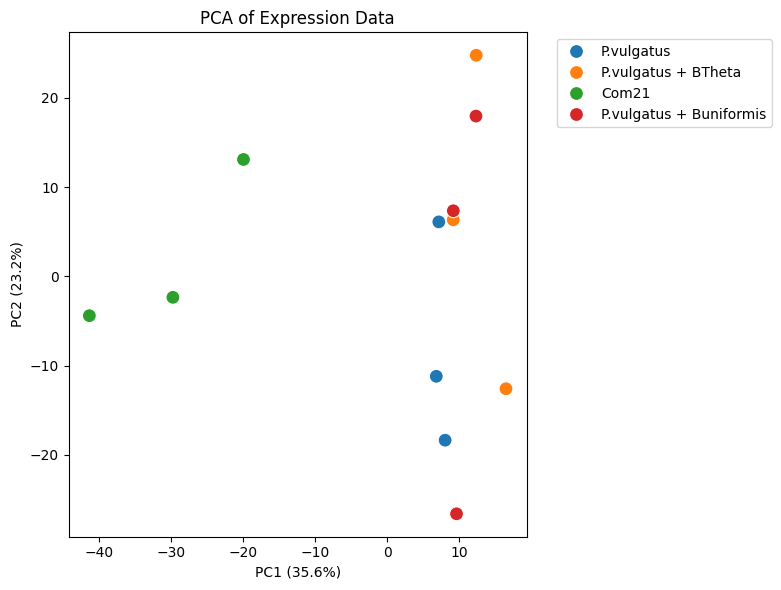

In [34]:


# 2. Transpose so samples are rows, genes are columns
filtered_df_T = filtered_df.T

# 4. Run PCA
pca = PCA(n_components=2)
pc = pca.fit_transform(filtered_df_T)
pca_masked_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=filtered_df_T.index)

# 5. Map sample names to conditions (make sure you have this dictionary!)

pca_masked_df['Condition'] = pca_masked_df.index.map(sample_to_condition)

# 6. Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_masked_df, x='PC1', y='PC2', hue='Condition', s=100)
plt.title('PCA of Expression Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/PCA/after_gene_removal/Pvulgatus")
plt.show()

## Mean-Variance Blot of new cleaned Data

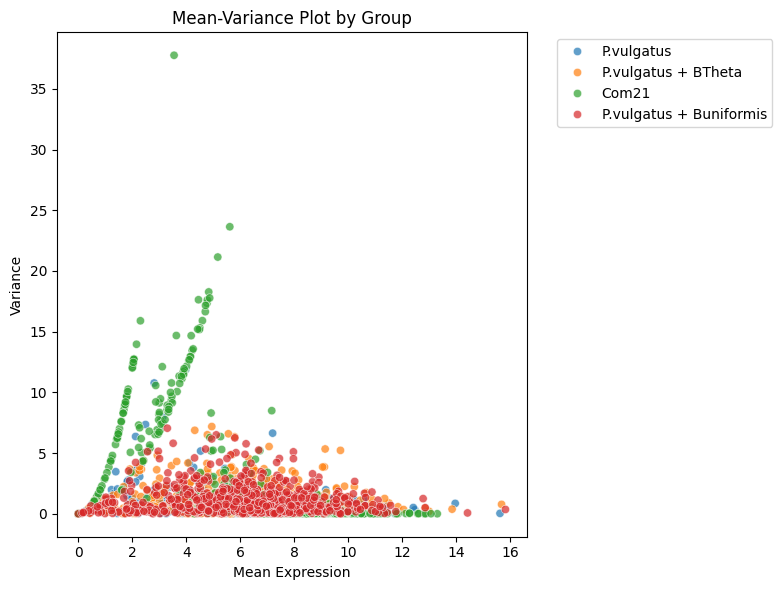

In [35]:
# Create group info DataFrame
group_df = pd.Series(sample_to_condition).to_frame('Group')

# Calculate mean/variance per group per gene
grouped = {}
for group in group_df['Group'].unique():
    cols = group_df[group_df['Group'] == group].index
    means = filtered_df[cols].mean(axis=1)
    variances = filtered_df[cols].var(axis=1)
    grouped[group] = pd.DataFrame({'Gene': filtered_df.index, 'Mean': means, 'Variance': variances, 'Group': group})

mv_df = pd.concat(grouped.values(), ignore_index=True)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=mv_df, x='Mean', y='Variance', hue='Group', alpha=0.7)
plt.title("Mean-Variance Plot by Group")
plt.xlabel("Mean Expression")
plt.ylabel("Variance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Mean-Variance_Blot/Pvulgatus_combined")
plt.show()

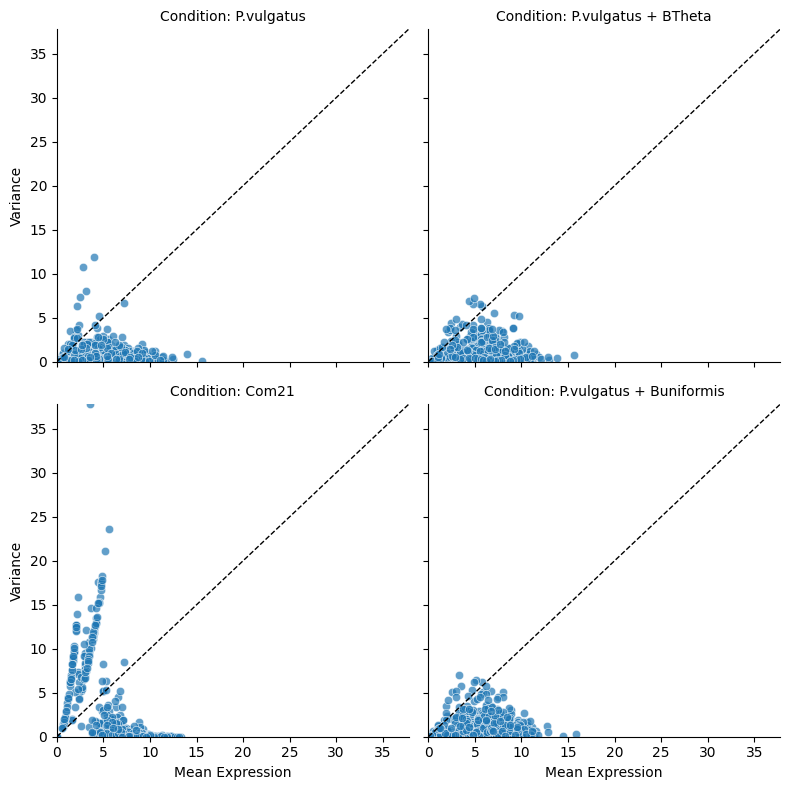

In [36]:
# Overall limits so facets are comparable
global_min = np.nanmin(mv_df[['Mean','Variance']].values)
global_max = np.nanmax(mv_df[['Mean','Variance']].values)
lims = [global_min, global_max]

g = sns.FacetGrid(mv_df, col='Group', col_wrap=2, sharex=True, sharey=True, height=4)

# Scatter in each facet
g.map_dataframe(sns.scatterplot, x='Mean', y='Variance', alpha=0.7)

# Add the diagonal in each facet
def add_diag(data, **kws):
    ax = plt.gca()
    ax.plot(lims, lims, ls='--', color='k', lw=1)

g.map_dataframe(add_diag)

# Tidy up
g.set_axis_labels("Mean Expression", "Variance")
g.set_titles("Condition: {col_name}")
for ax in g.axes.flat:
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Transcriptomics Quality Check/Mean-Variance_Blot/Pvulgatus_single")
plt.show()